In [1]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Styling

sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (10,4)

In [3]:
#Importing the data

df = pd.read_parquet(r"C:\Users\Admin\Documents\Fintech\90-Day-Fintech-AI\stage-01-reboot\day-01-pandas-cleaning\data\sp500_clean.parquet")

In [4]:
# Observing the number of columns and rows
print(df.shape)

(619040, 7)


In [5]:
#Identifying the number of tickers

print(df['Name'].nunique())

505


## Computing Daily Returns

In [6]:
# Sorting the data

df = df.sort_values(['Name', 'date'])
df["ret"] = (
    df.groupby("Name")["close"]
      .pct_change()
)

In [7]:
df.sort_values('ret' , ascending = False)

,date,open,high,low,close,volume,Name,ret
349477,2016-05-20,35.80,36.320,35.55,35.91,997954,LNT,1.009513
581387,2013-04-19,81.55,85.900,80.10,85.60,24894974,VRTX,0.619066
39639,2016-04-22,3.19,3.990,3.18,3.99,143265305,AMD,0.522901
581684,2014-06-24,98.02,98.800,89.93,93.53,25236837,VRTX,0.404144
425051,2017-09-15,43.13,43.375,42.81,43.20,7608237,NWL,0.402142
...,...,...,...,...,...,...,...,...
612745,2013-02-08,27.01,27.640,27.01,27.09,1206284,XYL,NaN
614004,2013-02-08,63.70,65.490,63.66,65.30,7190051,YUM,NaN
615263,2013-02-08,75.02,75.990,74.96,75.85,911179,ZBH,NaN
616522,2013-02-08,24.03,24.210,23.95,24.14,2104483,ZION,NaN


## Rolling 30-Day Realized Volatility
  - Volatility is annualized standard deviation of returns

In [8]:
rolling  = (
    df.groupby("Name")["ret"]
      .rolling(window = 30, min_periods = 30)
      .std()
      .reset_index(level = 0, drop = True)
)
df["Volatility_30d"] = rolling*np.sqrt(252)

In [9]:
df.sort_values(by = ['ret','Volatility_30d'], ascending = False)

,date,open,high,low,close,volume,Name,ret,Volatility_30d
349477,2016-05-20,35.80,36.320,35.55,35.91,997954,LNT,1.009513,3.309071
581387,2013-04-19,81.55,85.900,80.10,85.60,24894974,VRTX,0.619066,1.810263
39639,2016-04-22,3.19,3.990,3.18,3.99,143265305,AMD,0.522901,1.644416
581684,2014-06-24,98.02,98.800,89.93,93.53,25236837,VRTX,0.404144,1.239360
425051,2017-09-15,43.13,43.375,42.81,43.20,7608237,NWL,0.402142,1.505213
...,...,...,...,...,...,...,...,...,...
612745,2013-02-08,27.01,27.640,27.01,27.09,1206284,XYL,NaN,NaN
614004,2013-02-08,63.70,65.490,63.66,65.30,7190051,YUM,NaN,NaN
615263,2013-02-08,75.02,75.990,74.96,75.85,911179,ZBH,NaN,NaN
616522,2013-02-08,24.03,24.210,23.95,24.14,2104483,ZION,NaN,NaN


## Top / Bottom Performers
- Total Return over the last 252 Trading Days (~1year)

In [10]:
trailing_1y = (
    df[df["date"] >= df["date"].max() -
        pd.Timedelta(days = 365)]
        .groupby("Name")["ret"]
        .apply(lambda x: (1+x).prod() - 1)
        .sort_values(ascending = False)
)
top_10 = trailing_1y.head(10)
bottom_10 = trailing_1y.tail(10)

In [11]:
top_10.to_csv("top_performers.csv", header = ["total_return"])
bottom_10.to_csv("top_losers.csv", header = ["total_return"])

## Exploratory Data Analysis

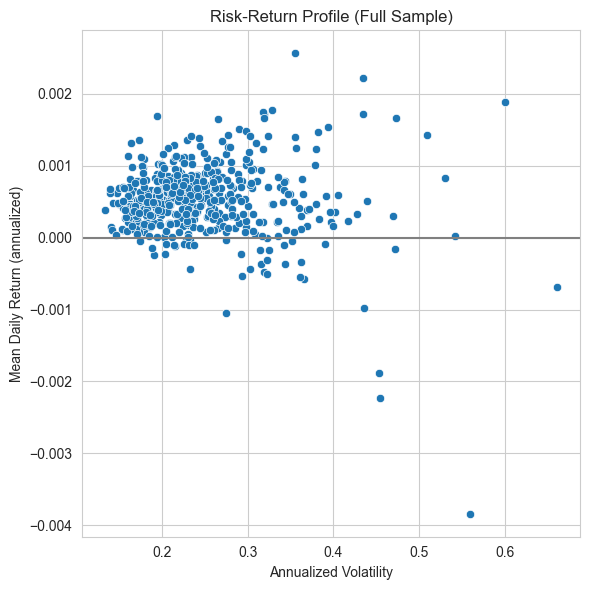

In [12]:
# Heatmap : 30-day Volatility vs Mean Daily Return'

summary = (
    df.groupby("Name")
      .agg(mean_ret=("ret", "mean"),
           vol=("ret", lambda x: np.std(x, ddof=1) * np.sqrt(252)))
      .dropna()
)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=summary, x="vol", y="mean_ret")
plt.title("Risk-Return Profile (Full Sample)")
plt.xlabel("Annualized Volatility")
plt.ylabel("Mean Daily Return (annualized)")
plt.axhline(0, color="grey")
plt.tight_layout()
plt.savefig("risk_return.png", dpi=300)

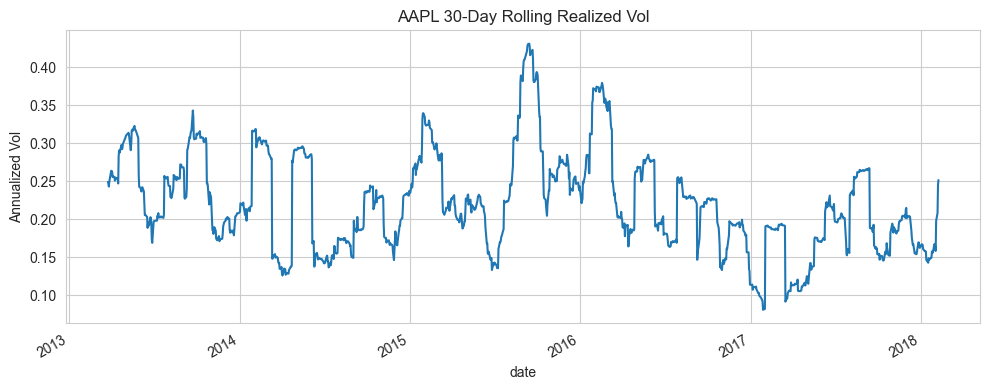

In [15]:
# Rolling Volatility for a single ticker (AAPL)

aapl = df[df["Name"] == "AAPL"].copy()
plt.figure()
aapl.set_index("date")["Volatility_30d"].plot()
plt.title("AAPL 30-Day Rolling Realized Vol")
plt.ylabel("Annualized Vol")
plt.tight_layout()
plt.savefig("aapl_vol.png", dpi=300)

In [16]:
df.to_parquet("rolling_vol.parquet")

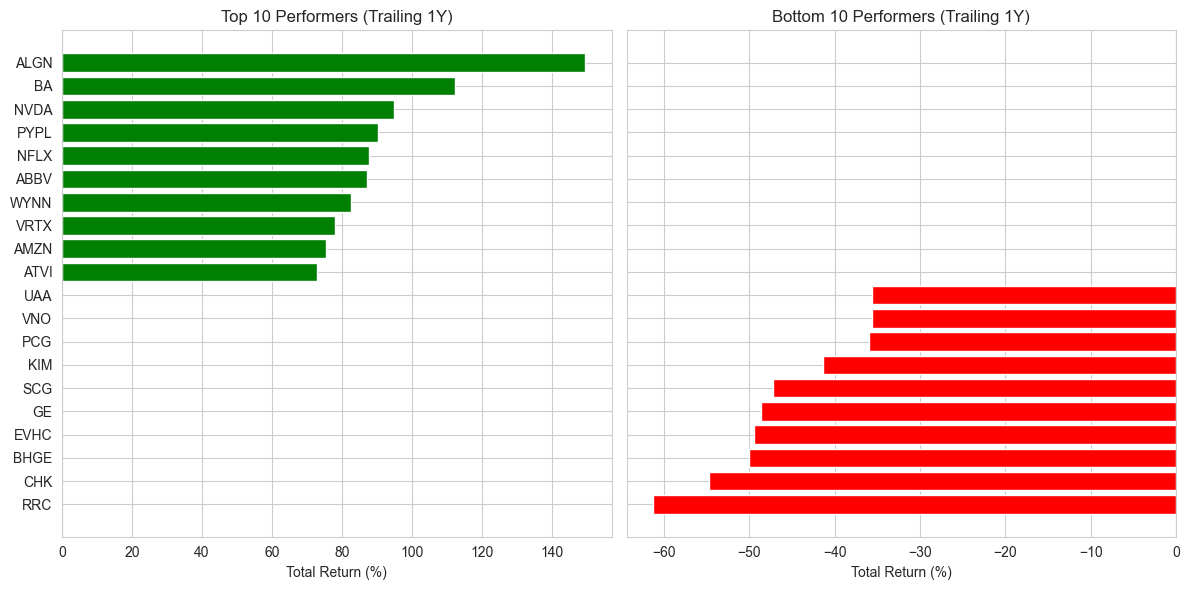

In [17]:
# Convert returns to percentages for display
top_10_pct = top_10 * 100
bottom_10_pct = bottom_10 * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Top 10 ---
axes[0].barh(top_10_pct.index, top_10_pct.values, color="green")
axes[0].set_title("Top 10 Performers (Trailing 1Y)")
axes[0].set_xlabel("Total Return (%)")
axes[0].invert_yaxis()  # highest at top

# --- Bottom 10 ---
axes[1].barh(bottom_10_pct.index, bottom_10_pct.values, color="red")
axes[1].set_title("Bottom 10 Performers (Trailing 1Y)")
axes[1].set_xlabel("Total Return (%)")

plt.tight_layout()
plt.show()
